## Setting up remote LLM

In [21]:
import os, getpass
from dotenv import load_dotenv, find_dotenv

def ensure_env(var: str):
    """
    Ensure that a given environment variable is set.
    1. Try to load from .env.local if it exists.
    2. If not found, ask the user securely.
    """
    dotenv_path = find_dotenv(".env.local")
    if dotenv_path:
        load_dotenv(dotenv_path)

    value = os.getenv(var)
    if not value:
        value = getpass.getpass(f"Enter value for {var}: ")
        os.environ[var] = value

    return value


# Example: choose which variable you need
key = ensure_env("OPENAI_API_KEY")
# key = ensure_env("OLLAMA_API_KEY")

# Example usage
from langchain_openai import ChatOpenAI
openai_llm = ChatOpenAI(model="gpt-4o")
result = openai_llm.invoke("Hello world")
print(result.content)


# from langchain_google_genai import ChatGoogleGenerativeAI
# google_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
# result = google_llm.invoke("Hello world")
# print(result.content)

Hello! How can I assist you today?


## Setting up LLM locally

Let's also try to get a local LLM setup with Langgraph. 

There are a few ways to do this. We are going to use chat model provided by Langchain due the ease of integration and avilable interfaces. For example, if you look at `OllamaLLM` and `ChatOllama`, the later comes with build if functionality to easily do tool calling. Wrap input output with different formats (e.g. user input, ai output, system input etc.)

In [22]:
from langchain_ollama import OllamaLLM, ChatOllama

# Initialize OllamaLLM
ollama_llm = OllamaLLM(model="llama3.2:latest")
ollama_chat_llm = ChatOllama(model="llama3.2:latest")

result_llm = ollama_llm.invoke("Hello world")
result_chat_llm = ollama_chat_llm.invoke("Hello world")

print(repr(result_llm)) # repr ensures special characters (like newlines, tabs, etc.) are visible.
print("-"*100)
print(repr(result_chat_llm))



"Hello! It's nice to meet you. Is there something I can help you with or would you like to chat?"
----------------------------------------------------------------------------------------------------
AIMessage(content="Hello! It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2025-10-16T21:45:56.61988Z', 'done': True, 'done_reason': 'stop', 'total_duration': 697503459, 'load_duration': 280828625, 'prompt_eval_count': 27, 'prompt_eval_duration': 17914334, 'eval_count': 25, 'eval_duration': 374094539, 'model_name': 'llama3.2:latest'}, id='run--d17ad99c-cc1e-436f-8870-fff35f5d0405-0', usage_metadata={'input_tokens': 27, 'output_tokens': 25, 'total_tokens': 52})


In [23]:
messages = "Give me fun fact about Canberra"
result_llm = ollama_llm.invoke(messages)
print(f'--------------------Type of result_llm var {type(result_llm)}')

print(result_llm)

--------------------Type of result_llm var <class 'str'>
Here's a fun fact about Canberra:

Canberra, the capital city of Australia, was actually designed to be the "City of Nature". The city's designers chose not to build any high-rise buildings or tall chimneys, in an effort to minimize its impact on the surrounding environment. As a result, Canberra has more tree cover than any other Australian capital city, and is often referred to as the "green capital" of Australia.


In [24]:
result_llm.response_metadata # There won't be any meta data we can access

AttributeError: 'str' object has no attribute 'response_metadata'

In [25]:
result_chat_llm = ollama_chat_llm.invoke(messages)
print(f'--------------------Type of result_llm var {type(result_chat_llm)}')

print(result_chat_llm)

--------------------Type of result_llm var <class 'langchain_core.messages.ai.AIMessage'>
content="Here's a fun fact about Canberra:\n\nDid you know that the city of Canberra is home to more than 170 memorials, monuments and landmarks dedicated to Australians who have served in war? These include the Australian War Memorial, which is one of Australia's most visited attractions, as well as numerous other memorials and monuments across the city. This emphasis on remembrance and commemoration reflects Canberra's role as the national capital and its commitment to honoring Australia's history and sacrifice." additional_kwargs={} response_metadata={'model': 'llama3.2:latest', 'created_at': '2025-10-16T21:46:08.215263Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2301827958, 'load_duration': 100191875, 'prompt_eval_count': 31, 'prompt_eval_duration': 118756917, 'eval_count': 96, 'eval_duration': 1949476920, 'model_name': 'llama3.2:latest'} id='run--51c7b981-7a50-45e8-8150-fb1cd531

In [26]:
result_chat_llm.response_metadata

{'model': 'llama3.2:latest',
 'created_at': '2025-10-16T21:46:08.215263Z',
 'done': True,
 'done_reason': 'stop',
 'total_duration': 2301827958,
 'load_duration': 100191875,
 'prompt_eval_count': 31,
 'prompt_eval_duration': 118756917,
 'eval_count': 96,
 'eval_duration': 1949476920,
 'model_name': 'llama3.2:latest'}

What is `AIMessage`?

It is a class. There are other classes like `HumanMessage`, `SystemMessage`, etc. They are classes (from `langchain_core.messages`) that represent different kinds of chat messages.
- HumanMessage -> a message coming from the user.
- AIMessage -> a message coming from the model.

They bring structure, clarity, interoperability and other advantages. 
They don't just store text (content). They can also hold metadata (additional_kwargs, response_metadata, id, etc.). We can immediately know who said what (AI vs human), instead of guessing.

In [27]:
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching consciousness?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="John"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn are thoughts the same as consciousness?", name="John"))

for m in messages:
    # print(repr(m))
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching consciousness?
================================ Human Message =================================
Name: John

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: John

I want to learn are thoughts the same as consciousness?


## Tools

Tools enable a model to interact with external systems. These systems such as APIs or databases typically require structured inputs rather than natural language. By binding a tool, the model learns the tool’s input schema and can invoke it appropriately in response to user prompts, for example by making an API request or calling a function. The tool then executes the action and returns its output in the expected structured format.

For instance we will show you how you can bind `Python functions` with `ChatModel.bind_tools(function)`.

In [28]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# ollama_llm_with_tools = ollama_llm.bind_tools([multiply]) # if you try to do this you will get an AttributeError: 'OllamaLLM' object has no attribute 'bind_tools'
# ollama_chat_llm_with_tools = ollama_chat_llm.bind_tools([multiply])

# OPTIONAL
openai_llm_with_tools = openai_llm.bind_tools([multiply])
# google_llm_with_tools = google_llm.bind_tools([multiply])

In [39]:
tool_call_openai = openai_llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="John")])
tool_call_openai.tool_calls


#OPTIONAL
# tool_call_ollama = ollama_chat_llm_with_tools.invoke([HumanMessage(content="What is 2 multiplied by 3", name="John")])
# tool_call_ollama = ollama_chat_llm_with_tools.invoke([HumanMessage(content="multiply 2 by 3", name="John")])
# tool_call_ollama.tool_calls


# tool_call_ollama = google_llm_with_tools.invoke([HumanMessage(content="multiply 2 by 3", name="John")])
# tool_call_ollama.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_8nqYCY53TgtcPhszRfJ5tiEN',
  'type': 'tool_call'}]

## Graph State

When working with LangGraph, we don’t just send or receive messages once. We build workflows where messages flow between steps. To make this possible, we need a way to store and carry messages along the workflow. This stored context is what we call the `state`.

In LangGraph, we often define the state with a Python type so it’s clear what data it holds. For example, here we say the `state` is a dictionary with one key, `messages`, which contains a list of all messages `(AnyMessage)` exchanged during the workflow:

AnyMessage is a type alias. It could be HumanMessage | AIMessage | SystemMessage | ToolMessage | FunctionMessage

In [30]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## Reducers

As our workflow runs, new messages keep getting added to the state. But how should the graph update the state when multiple steps try to write to the same key? That’s where `reducers` come in.

A `reducer` is just a rule that explains how to combine old and new values. For messages, the natural rule is to `append` new messages to the existing list rather than overwrite it.

LangGraph makes this easy by letting us annotate a state field with a reducer function. For example, here we use `add_messages` to ensure that every new message is added to the list:

P.S. Annotated in Python is a way to add extra information on top of a type. Here the Annotated says "this is a list of messages, and when new ones come in, use add_messages to combine them."

In [31]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [32]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on the human consciousness.", name="John")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. Do you want to start with the definition of consciousness?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='9b141bea-4a5d-4437-8581-8c9acffbf25d'),
 HumanMessage(content="I'm looking for information on the human consciousness.", additional_kwargs={}, response_metadata={}, name='John', id='4c9b5ebe-90d8-44c0-b778-a0448286c43f'),
 AIMessage(content='Sure, I can help with that. Do you want to start with the definition of consciousness?', additional_kwargs={}, response_metadata={}, name='Model', id='73c5820a-1103-4a39-ae68-815517dd9597')]

- Here we build the state type yourself. We must remember to import AnyMessage, Annotated, and add_messages. It’s explicit but a little verbose, especially since most people always want messages to be a list that appends.

- LangGraph already pre-defines a state with a messages key and the correct reducer (add_messages). By subclassing it, you automatically get the “sticky note” behaviour for messages. You only add extra fields if you want more state beyond messages.

In [33]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

## First graph -> Workflow

In [40]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

class MessagesState(MessagesState):
    pass

# node 1
def chat_llm_with_tools(state: MessagesState):
    return {"messages": [openai_llm_with_tools.invoke(state["messages"])]} 
    # return {"messages": [openai_llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_llm_with_tools", chat_llm_with_tools)
builder.add_edge(START, "chat_llm_with_tools")
builder.add_edge("chat_llm_with_tools", END)

# Compile graph
graph = builder.compile()

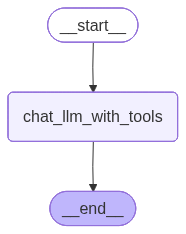

In [41]:

from IPython.display import Image, display
# View
# display(Image(graph.get_graph().draw_mermaid_png())) # The request to the remote Mermaid rendering service failed, or the rendering method isn’t supported in your current environment.

import nest_asyncio # Required for Jupyter Notebook to run async functions
nest_asyncio.apply()
from langchain_core.runnables.graph import MermaidDrawMethod

try:
    img_data = graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)

    display(Image(data=img_data, width=250))  #Change width to scale
except Exception as e:
    print("Could not display graph:", e)

## Running workflow

In [42]:
messages_no_tools = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages_no_tools['messages']:
    # print(repr(m))
    # print("-"*100)
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hi there! How can I assist you today?


In [43]:
# messages_with_tools = graph.invoke({"messages": HumanMessage(content="What is 2 multiplied by 3?")}) # Didn't work for me 🤷‍♂️
messages_with_tools = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages_with_tools['messages']:
    # print(repr(m))
    # print("-"*100)
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_yCAsU5XNlWW8BqTRsdouMYvY)
 Call ID: call_yCAsU5XNlWW8BqTRsdouMYvY
  Args:
    a: 2
    b: 3
